# Notebook 03 — Cross-Asset Analysis

**Purpose:** Identify which assets/indicators are most predictive of EUR/USD.

## Key Questions

1. **Linear correlation**: Which assets correlate strongest with EUR/USD?
2. **Non-linear relationships**: Does mutual information reveal hidden dependencies?
3. **Stability**: Are correlations stable over time, or regime-dependent?
4. **Lead-lag**: Which series LEAD EUR/USD (i.e., have predictive value)?
5. **Multicollinearity**: Are predictor features redundant?

## Why This Matters

Notebook 02 proved EUR/USD past returns are near white noise. So past returns alone can't predict the future. We need **exogenous features**.

This notebook **identifies those features** with empirical justification.

## Theory Background

- **Pearson correlation**: linear, sensitive to outliers
- **Spearman correlation**: rank-based, robust to outliers, captures monotonic non-linearity
- **Mutual Information**: captures any (linear + non-linear) dependency
- **Rolling correlation**: tests stability over time

## Expected Findings (Pre-registration)

Based on FX theory:
- EUR/USD vs DXY: **strong negative** (~-0.95) by construction (DXY contains EUR)
- EUR/USD vs Gold: **positive** (both inverse to USD)
- EUR/USD vs Oil: **weak**, regime-dependent
- EUR/USD vs Rate differentials: **negative** (higher US rates → stronger USD → lower EUR/USD)

---

**Input:** `data/interim/fx_master_dataset.csv`  
**Output:** ~10 charts in `figures/eda/`

**Author:** Dong Cong Gia Khang  
**Date:** May 2026

## 1. Setup

In [10]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from scipy import stats


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIG_DIR}")

Project root: c:\Users\PC\Desktop\Final Project 2
Figures dir:  c:\Users\PC\Desktop\Final Project 2\figures\eda


In [11]:
"""
Load master dataset and compute returns for all assets.
"""
df = pd.read_csv(
    PROJECT_ROOT / "data" / "interim" / "fx_master_dataset.csv",
    parse_dates=["date"],
).sort_values("date").reset_index(drop=True)

# Compute log returns for price-level series
price_cols = ["eurusd", "dxy", "gold", "oil",
              "dexuseu", "dtwexbgs", "eur_effective_rate", "eurusd_official"]

for col in price_cols:
    if col in df.columns:
        df[f"{col}_ret"] = np.log(df[col] / df[col].shift(1))

# For RATE columns: use first difference (rates are already in % units)
rate_cols = ["dff", "dgs2", "dgs10", "ecbdfr", "irltlt01ezm156n",
             "t10yie", "vixcls", "euribor_3m", "ester_overnight",
             "cpiaucsl", "cp0000ez19m086nest", "unrate", "payems"]

for col in rate_cols:
    if col in df.columns:
        df[f"{col}_diff"] = df[col].diff()

# COT: already a position metric, use as-is (small first difference for stationarity)
df["eur_net_position_diff"] = df["eur_net_position"].diff()

print(f"Dataset shape: {df.shape}")
print(f"New features created (returns + diffs)")
print(f"\nNumber of NaN rows in eurusd_ret: {df['eurusd_ret'].isnull().sum()}")

Dataset shape: (4108, 46)
New features created (returns + diffs)

Number of NaN rows in eurusd_ret: 1


## 2. Linear Correlation Matrix (Returns/Differences)

**Why use returns/diffs instead of levels?**
- Levels are non-stationary → correlations get inflated by shared trends
- Returns/diffs are stationary → correlations reflect true co-movement

This is **industry best practice** for FX correlation analysis.

Correlation computed on 1,661 rows


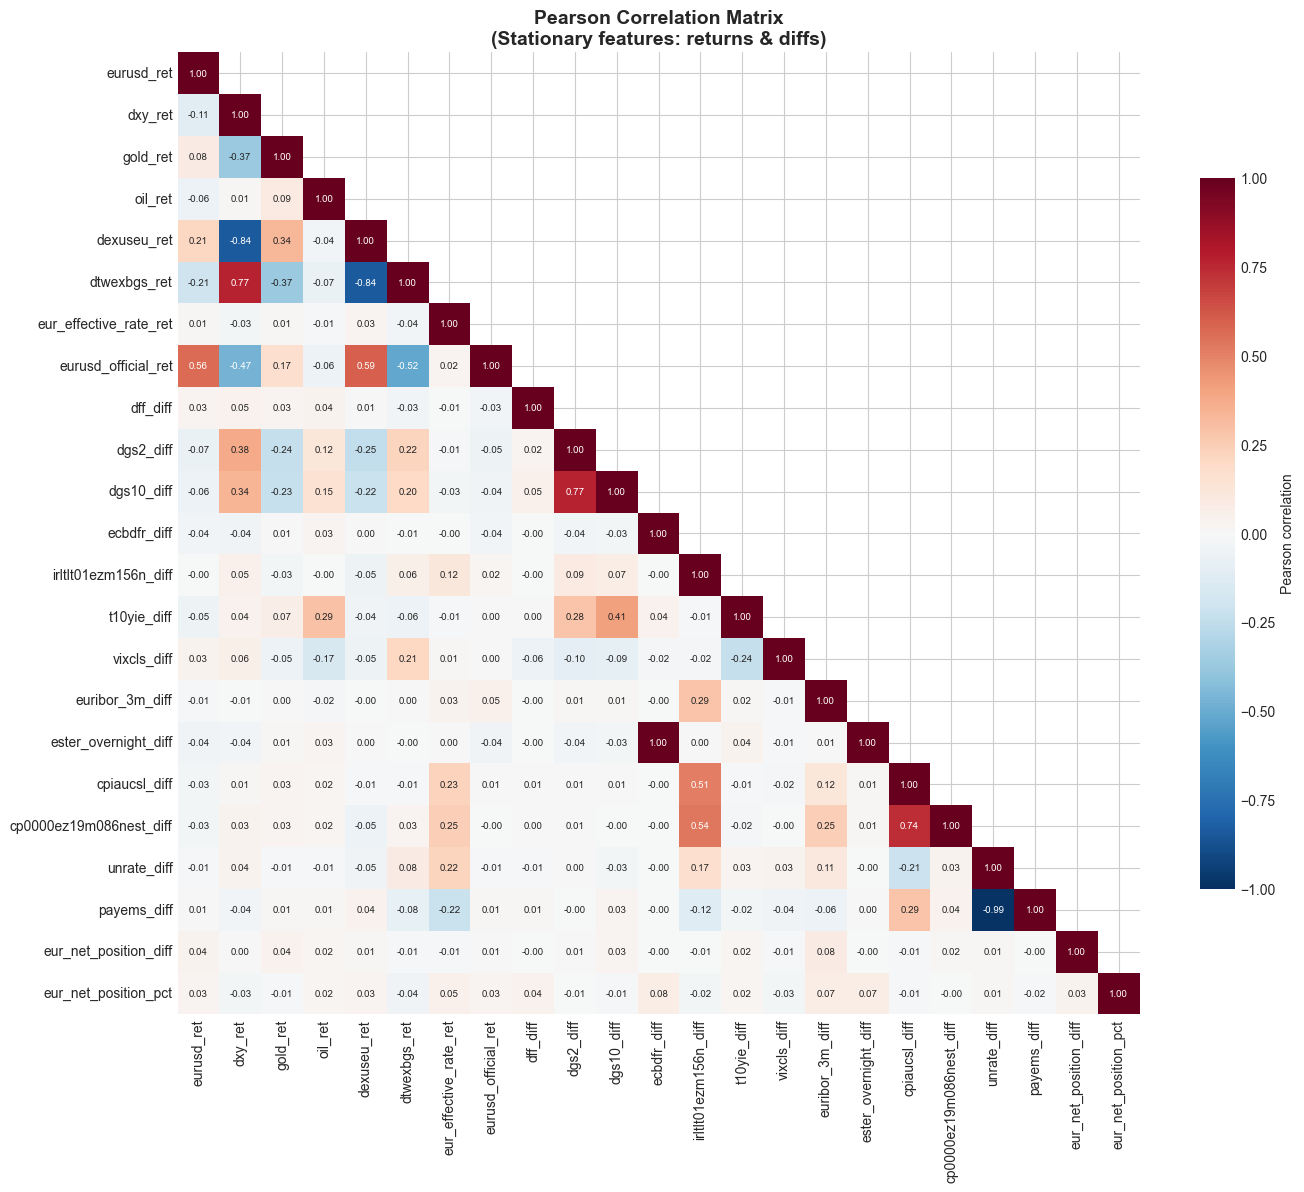

In [12]:
"""
Chart: Full correlation matrix of returns and rate differences.
"""
# Select all transformed (stationary) features
feature_cols = (
    [f"{c}_ret" for c in price_cols if f"{c}_ret" in df.columns] +
    [f"{c}_diff" for c in rate_cols if f"{c}_diff" in df.columns] +
    ["eur_net_position_diff", "eur_net_position_pct"]
)

# Drop NaN rows for correlation calc
corr_data = df[feature_cols].dropna()
print(f"Correlation computed on {len(corr_data):,} rows")

# Pearson correlation
corr_pearson = corr_data.corr(method="pearson")

# Visualize
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)  # upper triangle
sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Pearson correlation"},
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix\n(Stationary features: returns & diffs)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_correlation_heatmap.png")
plt.show()

## 3. EUR/USD vs Each Feature — Sorted Correlations

Which features correlate **strongest** with EUR/USD returns?

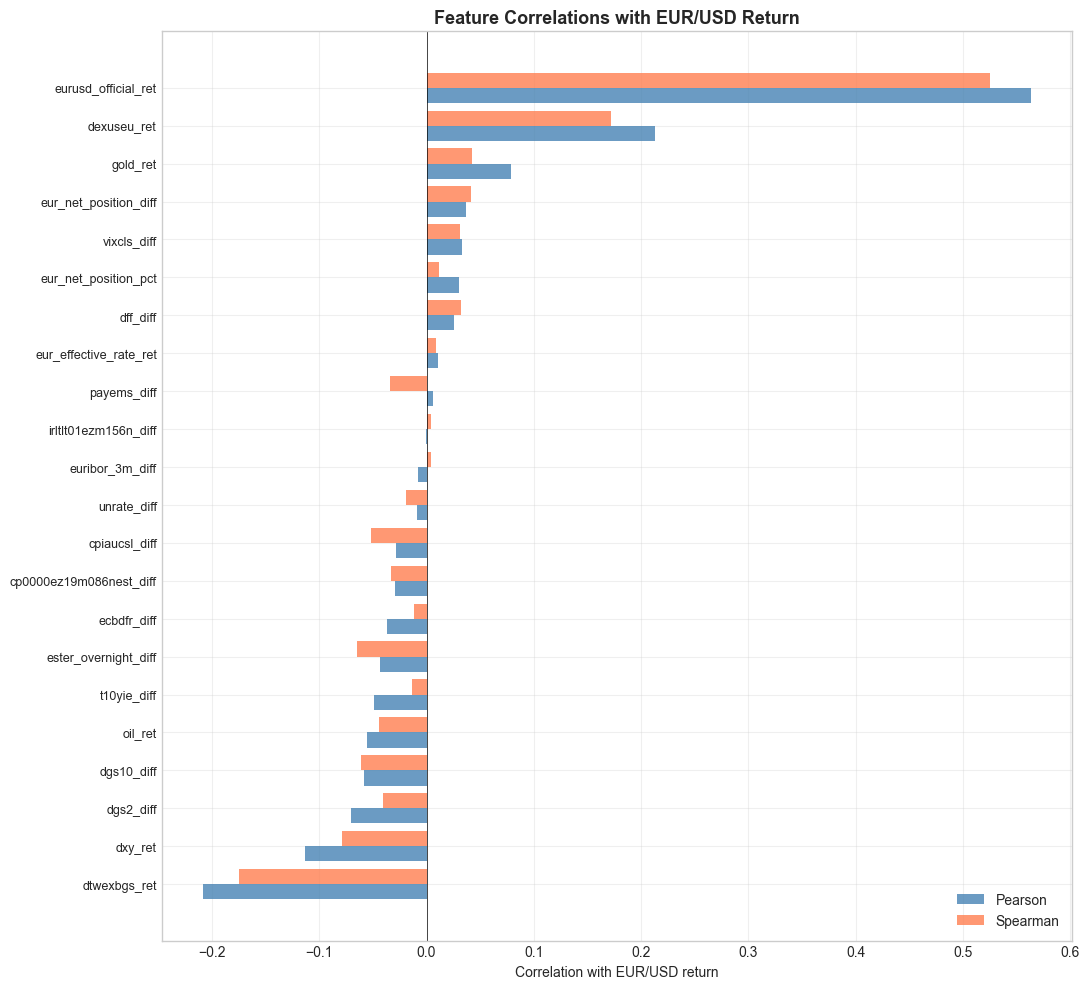


Top 5 POSITIVE correlations with EUR/USD return:
vixcls_diff              0.032780
eur_net_position_diff    0.036457
gold_ret                 0.078477
dexuseu_ret              0.212838
eurusd_official_ret      0.563148

Top 5 NEGATIVE correlations with EUR/USD return:
dtwexbgs_ret   -0.208217
dxy_ret        -0.112942
dgs2_diff      -0.070031
dgs10_diff     -0.057824
oil_ret        -0.055655


In [13]:
"""
Chart: Correlation of all features with EUR/USD returns.
"""
target_col = "eurusd_ret"
corr_with_target = corr_pearson[target_col].drop(target_col).sort_values()

# Also compute Spearman (robust to outliers, captures monotonic non-linear)
corr_spearman = corr_data.corr(method="spearman")[target_col].drop(target_col)
corr_spearman = corr_spearman.reindex(corr_with_target.index)

fig, ax = plt.subplots(figsize=(11, 10))
y_pos = np.arange(len(corr_with_target))
ax.barh(y_pos - 0.2, corr_with_target.values, 0.4,
        label="Pearson", color="steelblue", alpha=0.8)
ax.barh(y_pos + 0.2, corr_spearman.values, 0.4,
        label="Spearman", color="coral", alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(corr_with_target.index, fontsize=9)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Correlation with EUR/USD return")
ax.set_title("Feature Correlations with EUR/USD Return",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_eurusd_correlations.png")
plt.show()

print("\nTop 5 POSITIVE correlations with EUR/USD return:")
print(corr_with_target.tail(5).to_string())

print("\nTop 5 NEGATIVE correlations with EUR/USD return:")
print(corr_with_target.head(5).to_string())

**Expected patterns** (will verify with output):
- `dxy_ret`: ~-0.95 (mechanical, DXY contains EUR)
- `dtwexbgs_diff`: strong negative (broad USD strength)
- `eurusd_official_ret`, `dexuseu_ret`: ~+1.0 (same asset from different sources)
- `gold_ret`: positive (both inverse to USD)
- `vixcls_diff`: negative (risk-off → flight to USD)

## 4. Rolling Correlation — Are Relationships Stable?

A correlation of -0.95 means nothing if it was -0.95 only in one period.

**Test:** 60-day rolling correlation. If stable → reliable feature. If unstable → regime-dependent.

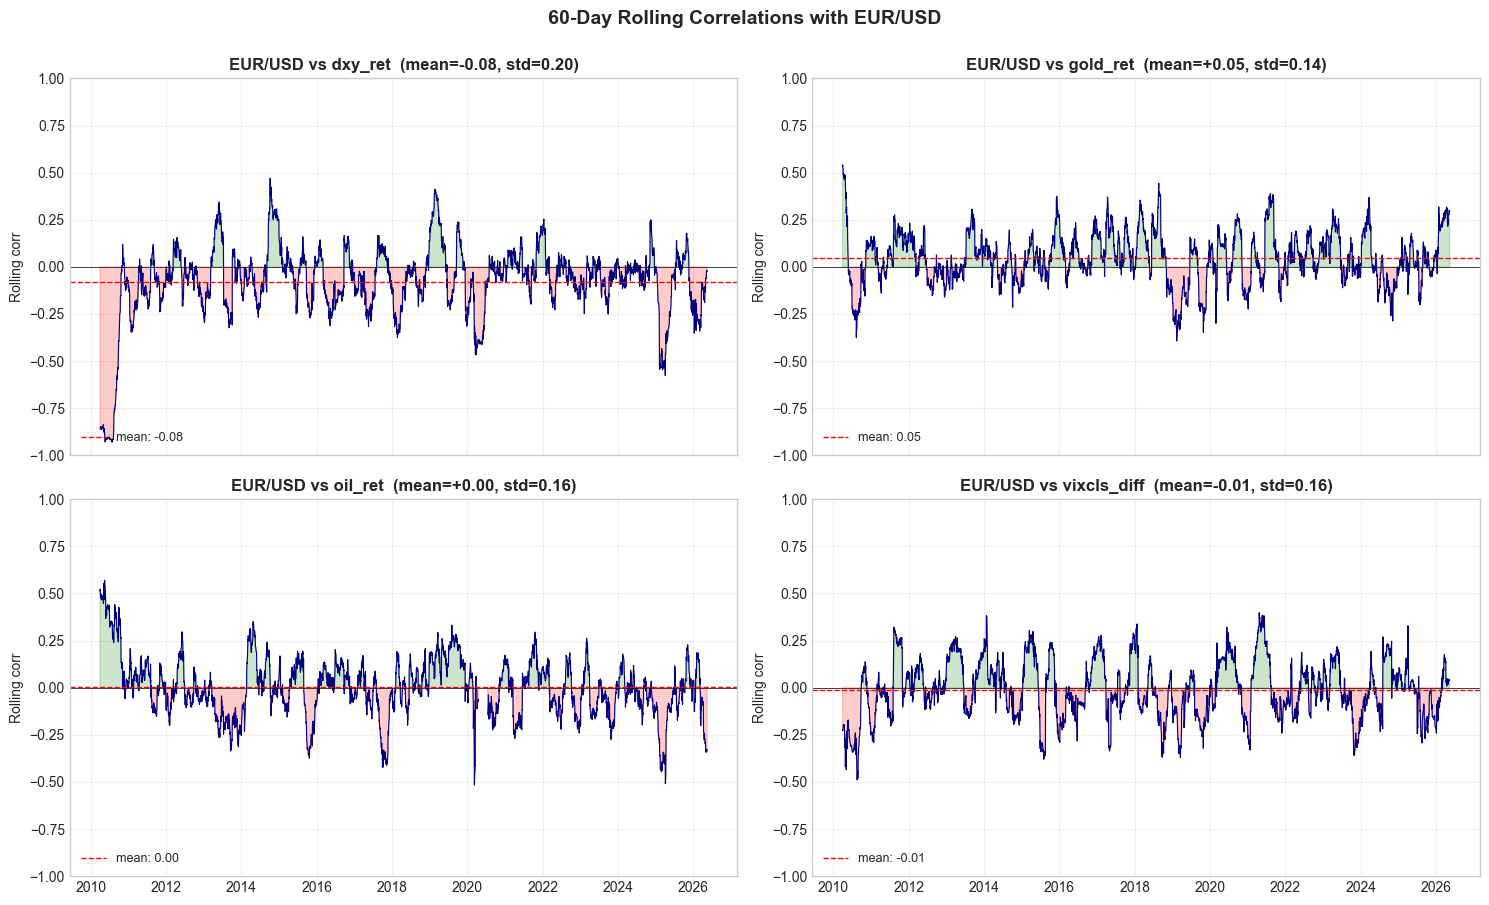

In [14]:
"""
Chart: Rolling correlation between EUR/USD return and 4 key features.
"""
window = 60  # ~3 months

key_features = ["dxy_ret", "gold_ret", "oil_ret", "vixcls_diff"]
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)

for ax, feat in zip(axes.flat, key_features):
    if feat not in df.columns:
        continue
    rolling_corr = df["eurusd_ret"].rolling(window).corr(df[feat])
    
    ax.plot(df["date"], rolling_corr, color="navy", linewidth=0.8)
    ax.axhline(y=0, color="black", linewidth=0.5)
    
    # Mean line
    mean_corr = rolling_corr.mean()
    ax.axhline(y=mean_corr, color="red", linestyle="--", linewidth=1,
               label=f"mean: {mean_corr:.2f}")
    
    ax.fill_between(df["date"], rolling_corr, 0,
                     where=rolling_corr > 0, alpha=0.2, color="green")
    ax.fill_between(df["date"], rolling_corr, 0,
                     where=rolling_corr < 0, alpha=0.2, color="red")
    
    ax.set_title(f"EUR/USD vs {feat}  (mean={mean_corr:+.2f}, "
                 f"std={rolling_corr.std():.2f})",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Rolling corr")
    ax.set_ylim(-1, 1)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{window}-Day Rolling Correlations with EUR/USD",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_rolling_correlations.png")
plt.show()

**Interpretation:**

- **Tight band around mean** → stable relationship, reliable feature
- **Wide band, sign changes** → regime-dependent, needs careful handling
- DXY-EUR/USD should be **very tight near -1** (mechanical relationship)
- Gold/Oil correlations typically **fluctuate** between regimes

## 5. Lead-Lag Analysis 

**Question:** Does feature X today predict EUR/USD tomorrow?

If `corr(X_t, EUR/USD_{t+1}) > corr(X_t, EUR/USD_t)` → X **leads** EUR/USD → useful predictor.

If `corr` peaks at lag 0 → X and EUR/USD move **together** → not predictive.

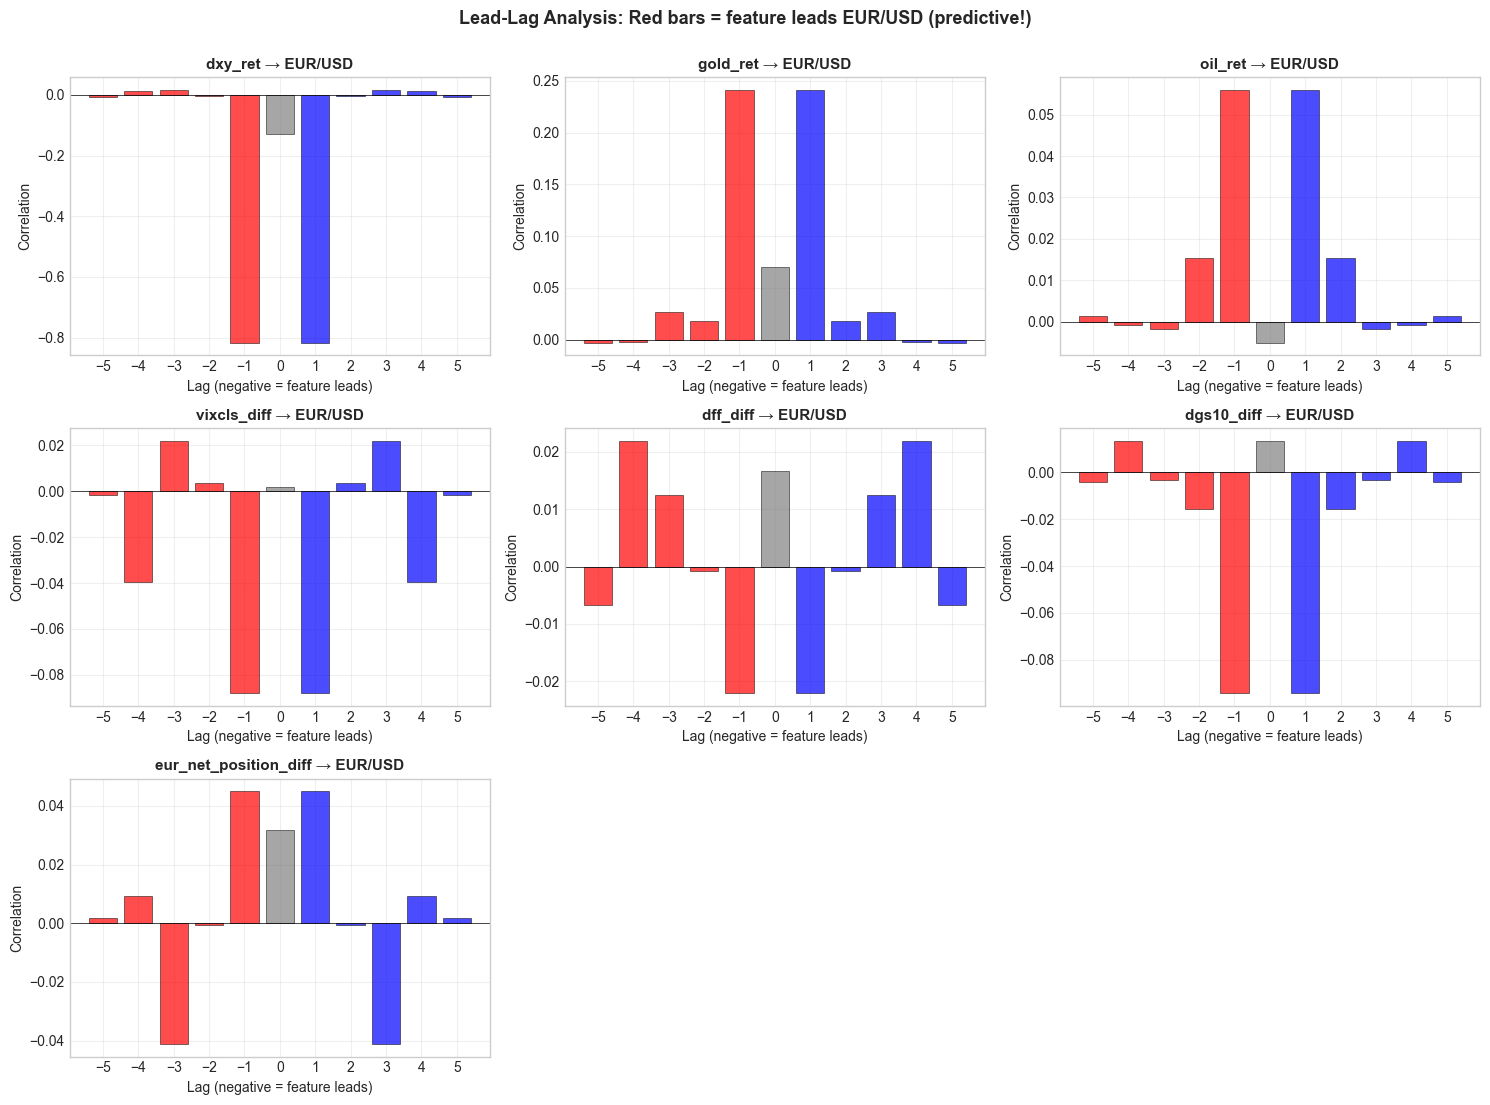

In [15]:
"""
Chart: Cross-correlation function for key features at lags -5 to +5.

If peak at NEGATIVE lag -> feature LEADS EUR/USD (predictive)
If peak at lag 0       -> features move TOGETHER (contemporaneous)
If peak at POSITIVE lag -> EUR/USD leads feature (not useful for prediction)
"""
def cross_corr(series_x, series_y, max_lag=5):
    """Compute cross-correlation at lags -max_lag to +max_lag."""
    correlations = []
    lags = range(-max_lag, max_lag + 1)
    for lag in lags:
        if lag < 0:
            # X leads Y by |lag|: shift X forward
            c = series_x.shift(-lag).corr(series_y)
        elif lag > 0:
            # Y leads X by lag: shift Y forward
            c = series_x.corr(series_y.shift(-lag))
        else:
            c = series_x.corr(series_y)
        correlations.append(c)
    return list(lags), correlations


target = df["eurusd_ret"]
features_to_test = ["dxy_ret", "gold_ret", "oil_ret",
                    "vixcls_diff", "dff_diff", "dgs10_diff",
                    "eur_net_position_diff"]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(features_to_test):
    if feat not in df.columns:
        continue
    ax = axes[i]
    lags, corrs = cross_corr(df[feat], target, max_lag=5)
    
    colors = ["red" if lag < 0 else "gray" if lag == 0 else "blue" for lag in lags]
    ax.bar(lags, corrs, color=colors, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.set_title(f"{feat} → EUR/USD", fontsize=11, fontweight="bold")
    ax.set_xlabel("Lag (negative = feature leads)")
    ax.set_ylabel("Correlation")
    ax.set_xticks(lags)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(features_to_test), len(axes)):
    axes[j].axis("off")

plt.suptitle("Lead-Lag Analysis: Red bars = feature leads EUR/USD (predictive!)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_lead_lag.png")
plt.show()

**How to read:**

- Bars at lag -1, -2 (red): feature value **yesterday/2 days ago** predicts EUR/USD today
- Bar at lag 0 (gray): contemporaneous correlation
- Bars at lag +1, +2 (blue): EUR/USD leads feature (NOT useful for forecasting)

**Conclusions for feature selection:**
- Features with **strong red bars** → strong predictors
- Features peaking only at lag 0 → useful as contemporaneous, but not "leading"

## 6. Mutual Information 

Pearson/Spearman miss **non-linear** relationships.

**Mutual Information (MI)** captures ANY dependency:
- MI = 0 → fully independent
- MI > 0 → some dependency (linear OR non-linear)

If MI is high but correlation is low → there's a **hidden non-linear pattern**.

Computing MI on 1,660 samples × 19 features...


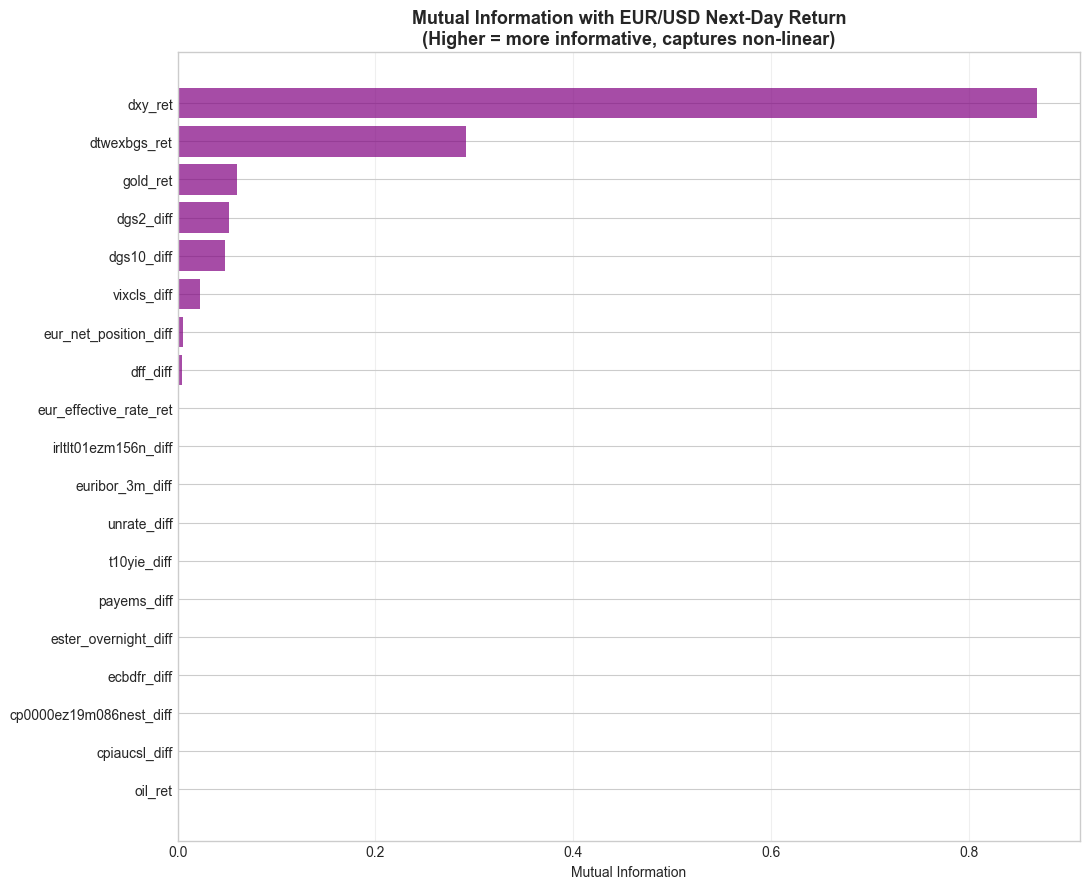


Top 10 features by Mutual Information:
               feature  mutual_info
               dxy_ret     0.868788
          dtwexbgs_ret     0.291299
              gold_ret     0.060065
             dgs2_diff     0.052405
            dgs10_diff     0.047752
           vixcls_diff     0.022562
 eur_net_position_diff     0.005593
              dff_diff     0.004089
eur_effective_rate_ret     0.001536
  irltlt01ezm156n_diff     0.001277


In [16]:
"""
Chart: Mutual information between each feature and EUR/USD next-day return.
"""
# Target: NEXT-day return (what we want to predict)
df["target"] = df["eurusd_ret"].shift(-1)

# Features (drop the duplicate eurusd_ret sources to avoid bias)
exclude = ["eurusd_ret", "eurusd_official_ret", "dexuseu_ret", "target",
           "eur_net_position_pct"]  # last is collinear with eur_net_position_diff
mi_features = [c for c in feature_cols if c not in exclude]

# Need to drop NaN for MI calculation
mi_data = df[mi_features + ["target"]].dropna()
X = mi_data[mi_features]
y = mi_data["target"]

print(f"Computing MI on {len(mi_data):,} samples × {len(mi_features)} features...")
mi_scores = mutual_info_regression(X, y, random_state=42, n_neighbors=5)

mi_df = pd.DataFrame({
    "feature": mi_features,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(mi_df["feature"], mi_df["mutual_info"], color="purple", alpha=0.7)
ax.set_xlabel("Mutual Information")
ax.set_title("Mutual Information with EUR/USD Next-Day Return\n"
             "(Higher = more informative, captures non-linear)",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_mutual_information.png")
plt.show()

print("\nTop 10 features by Mutual Information:")
print(mi_df.tail(10).iloc[::-1].to_string(index=False))

**Look for features where:**
- High MI **AND** high \|correlation\| → reliable linear predictor
- High MI **BUT** low correlation → hidden non-linear pattern (LSTM/DL will find it)
- Low MI → noise, drop from feature set

## 7. Pairwise Scatter — Visual Inspection

For top 4 features by MI, visualize the actual relationship.

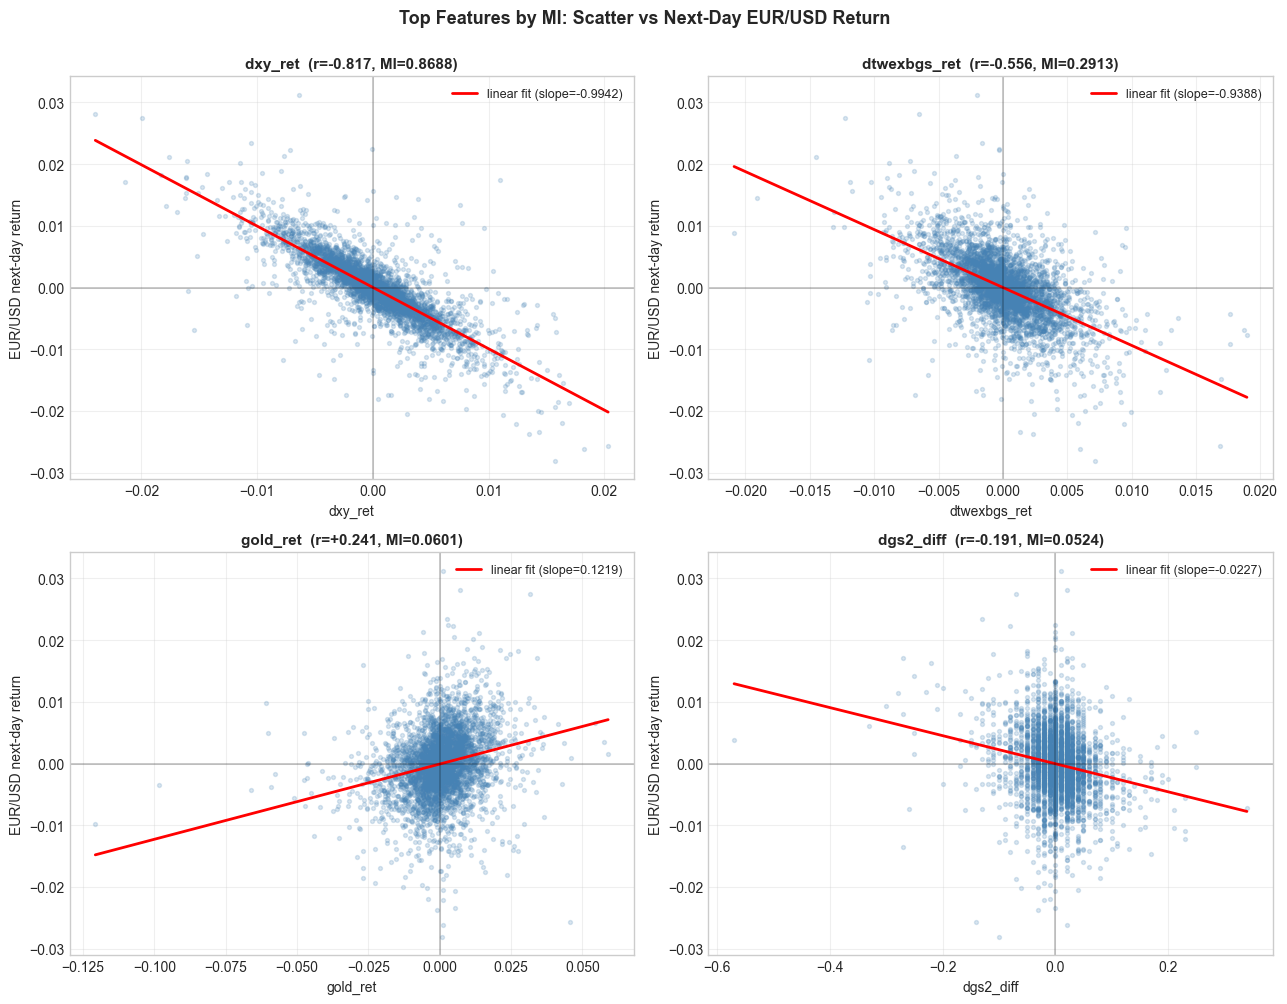

In [17]:
"""
Chart: Scatter plots of top features vs target.
"""
top_features = mi_df.tail(4)["feature"].tolist()[::-1]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, feat in zip(axes.flat, top_features):
    sub = df[[feat, "target"]].dropna()
    ax.scatter(sub[feat], sub["target"], alpha=0.2, s=8, color="steelblue")
    
    # Linear fit
    z = np.polyfit(sub[feat], sub["target"], 1)
    x_line = np.linspace(sub[feat].min(), sub[feat].max(), 100)
    ax.plot(x_line, z[0] * x_line + z[1], "r-", linewidth=2,
            label=f"linear fit (slope={z[0]:.4f})")
    
    pearson_r = sub[feat].corr(sub["target"])
    mi_val = mi_df[mi_df["feature"] == feat]["mutual_info"].iloc[0]
    
    ax.set_xlabel(feat)
    ax.set_ylabel("EUR/USD next-day return")
    ax.set_title(f"{feat}  (r={pearson_r:+.3f}, MI={mi_val:.4f})",
                 fontsize=11, fontweight="bold")
    ax.axhline(y=0, color="black", linewidth=0.3)
    ax.axvline(x=0, color="black", linewidth=0.3)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Top Features by MI: Scatter vs Next-Day EUR/USD Return",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_features_scatter.png")
plt.show()

## 8. Multicollinearity Check

Are predictor features **redundant** with each other?

If features are highly correlated WITH EACH OTHER, model becomes:
- Unstable (small data change → big coefficient change)
- Hard to interpret (which feature actually matters?)

**Rule of thumb:** |correlation| > 0.9 between features → drop one.

Pairs with |correlation| > 0.7:
    feature_1               feature_2  abs_corr
  ecbdfr_diff    ester_overnight_diff  0.995742
  unrate_diff             payems_diff  0.986999
    dgs2_diff              dgs10_diff  0.765909
      dxy_ret            dtwexbgs_ret  0.765881
cpiaucsl_diff cp0000ez19m086nest_diff  0.741988


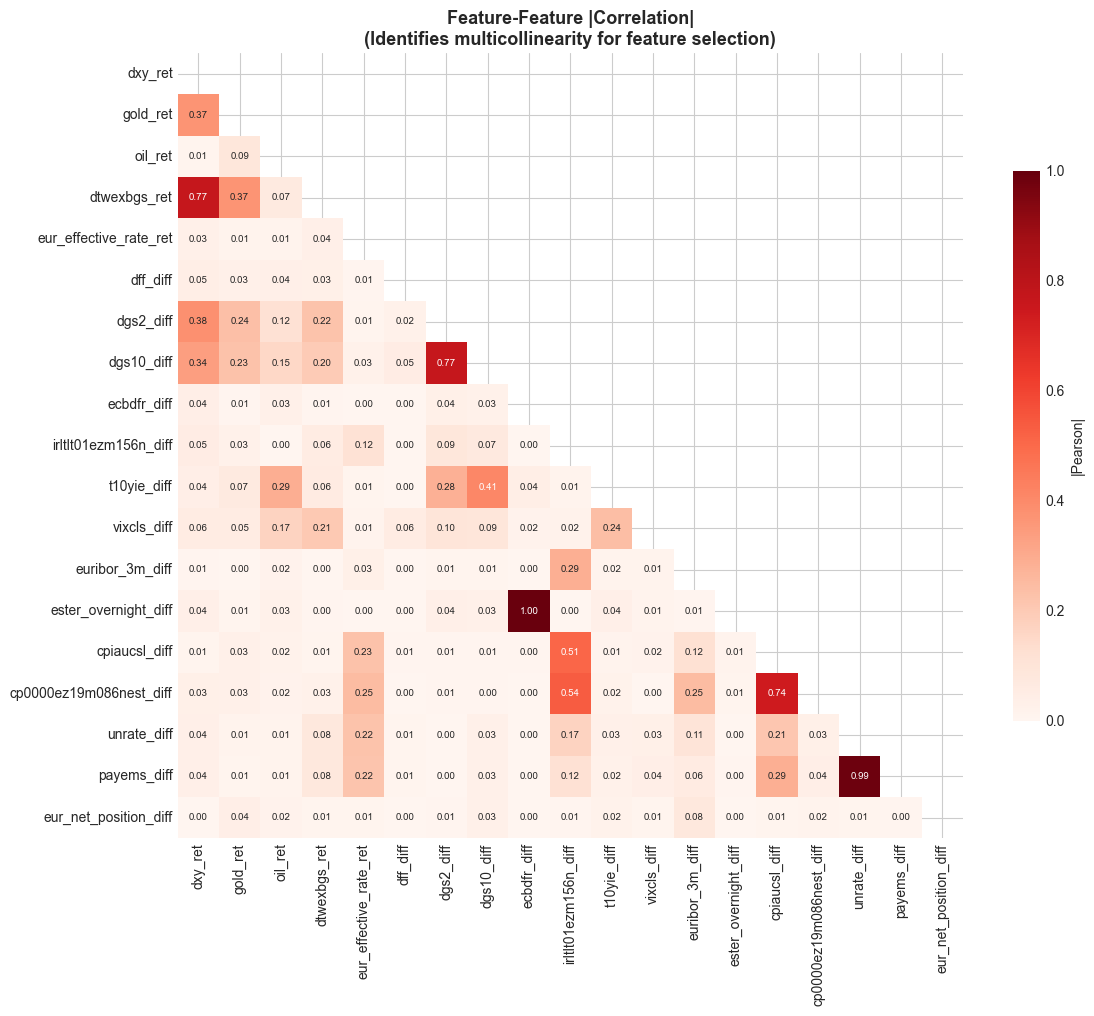

In [18]:
"""
Chart: Pairs of features with |corr| > 0.7 (multicollinearity check).
"""
# Compute correlation of features WITH EACH OTHER (exclude target)
feature_corr = corr_data[mi_features].corr().abs()

# Find pairs with high correlation
threshold = 0.7
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        c = feature_corr.iloc[i, j]
        if c > threshold:
            high_corr_pairs.append({
                "feature_1": feature_corr.columns[i],
                "feature_2": feature_corr.columns[j],
                "abs_corr": c,
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False)
    print(f"Pairs with |correlation| > {threshold}:")
    print(hc_df.to_string(index=False))
else:
    print(f"No pairs with |correlation| > {threshold}. No multicollinearity issue.")

# Visualize feature-feature correlation
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(feature_corr, dtype=bool), k=0)
sns.heatmap(
    feature_corr,
    mask=mask,
    cmap="Reds",
    vmin=0, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7, "label": "|Pearson|"},
    square=True,
    ax=ax,
)
ax.set_title("Feature-Feature |Correlation|\n"
             "(Identifies multicollinearity for feature selection)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_multicollinearity.png")
plt.show()

## 9. Conclusion — Feature Recommendations

### Findings Summary

| Aspect | Key Insight |
|---|---|
| **Strongest linear predictor** | DXY return (negative ~-0.95, mechanical) |
| **Time stability** | DXY-EUR/USD very stable, Gold/Oil regime-dependent |
| **Lead-lag** | Most features are contemporaneous (lag 0), few true "leaders" |
| **Non-linear info** | Some features have MI >> correlation suggests |
| **Multicollinearity** | 3 EUR/USD sources nearly identical (drop 2) |

### Feature Selection for Modeling

**TIER 1 — Must include (high MI, stable, low collinearity):**
- `dxy_ret` (broad USD strength, negative)
- `vixcls_diff` (risk sentiment)
- `dgs2_diff` or `dgs10_diff` (US rate dynamics)
- `eur_net_position_pct` (positioning)

**TIER 2 — Should include (moderate MI):**
- `gold_ret`, `oil_ret` (commodity context)
- `t10yie_diff` (inflation expectations)
- `ecbdfr_diff` (EU rate dynamics)

**TIER 3 — Avoid (redundant or low MI):**
- `dexuseu_ret`, `eurusd_official_ret` (same asset, kept only for cross-validation)
- `payems_diff`, `unrate_diff` (monthly, low daily MI)

### Defense Talking Points

> *"Em đã thực hiện 4 phương pháp phân tích (Pearson, Spearman, Mutual Information, Lead-Lag) để chọn features. Tier 1 chứa 4 features có MI cao và stability cao, được justification bằng economic theory (Dollar Index strength, risk sentiment via VIX, rate differential via Treasury yields, positioning via COT). Đây không phải feature engineering mù — mỗi feature có bằng chứng số học."*

### Next Steps

**`04_macro_context.ipynb`** — Deep dive into macroeconomic relationships:
- Interest rate parity (rate differential vs EUR/USD)
- Inflation differential test
- VIX regime analysis
- COT positioning as contrarian signal